In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [6]:
import pandas as pd

df = pd.read_csv('data.csv')
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Переводим столбец "Дата" в правильный формат

In [9]:
import pandas as pd

df = pd.read_csv('data.csv')

# Добавляем параметр format='mixed'
df['Дата'] = pd.to_datetime(df['Дата'], format='mixed', dayfirst=True)

# Проверяем формат
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [ ]:
grouped_df = ...

Вывести несколько первых строк сгруппированных данных

In [11]:
# группировка по номенклатуре и суммирование количества:
grouped_df = df.groupby('Номенклатура')['Количество'].sum().reset_index()

# Выводим первые 3 строки:
grouped_df.head(3)

,Номенклатура,Количество
0,product_0,119336
1,product_1,180771
2,product_10,11271


Нарисуйте график продаж у `grouped_df`

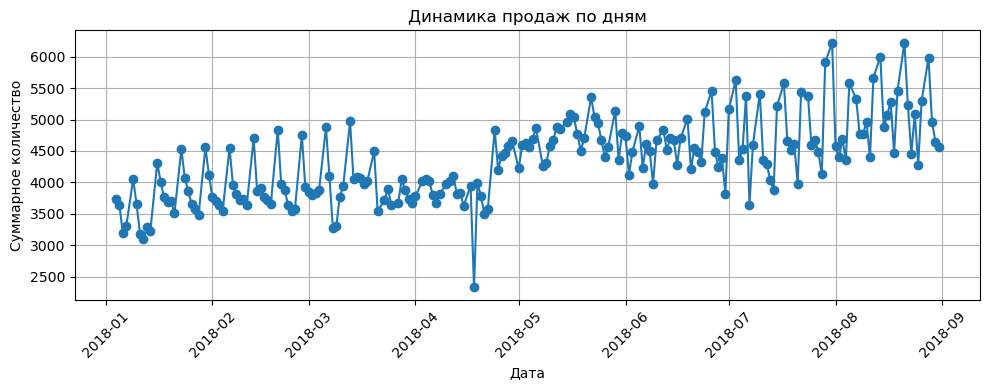

In [15]:
import matplotlib.pyplot as plt

# 1. Группируем количество по дате
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

# 2. Строим график
plt.figure(figsize=(10, 4))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], marker='o', color='tab:blue')

plt.title('Динамика продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Суммарное количество')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# На графике представлена динамика суммарных продаж за период с января по август 2018 года.
# В целом наблюдается устойчивый рост с увеличением объема продаж от -3 500 до -5 500 и выше единиц.
# Присутствует выраженная недельная цикличность (регулярные колебания спроса).
# Особенности:
# В середине апреля наблюдается сильный аномальный выброс вниз (падение ниже 2 500 единиц).
# Начиная с июля увеличивается амплитуда колебаний продаж.
# Максимум продаж достигается в августе (свыше 6 000 единиц), минимум — в середине апреля.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [17]:
# 1. Группируем по датам
daily_sales = df.groupby('Дата')['Количество'].sum().reset_index()

# 2. Находим дату с минимальной суммой продаж
outlier_date = daily_sales.loc[daily_sales['Количество'].idxmin()]
print("Дата с минимальным выбросом продаж:")
print(outlier_date)

Дата с минимальным выбросом продаж:
Дата          2018-04-18 00:00:00
Количество                   2326
Name: 88, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [18]:
import pandas as pd

# 1. Проверяем, что столбец 'Дата' в формате datetime
df['Дата'] = pd.to_datetime(df['Дата'])

# 2. Фильтруем данные:
# - Склад == 3
# - Месяцы: июнь (6), июль (7), август (8)
# - День недели: среда (в pandas среда — это 2, так как понедельник = 0)
filtered_df = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

# 3. Группируем по номенклатуре, считаем сумму продаж и находим кто лидер
top_product = filtered_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_product.sort_values(by='Количество', ascending=False)

# Выводим самый топовый товар
top_product.head(1)

,Номенклатура,Количество
1,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [ ]:
# Загрузка файла погоды и обработка дат

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r'C:\Users\Admin\Academica_Python\финал\Погода.csv.gz'

# 1. Читаем архив с rp5
weather = pd.read_csv(
    file_path, 
    skiprows=6, 
    sep=';', 
    compression='gzip', 
    encoding='cp1251',
    engine='python'
)

# 2. Возвращаем сдвинутую дату из индекса в обычный столбец
weather = weather.reset_index()

# 3. После reset_index():
#    - weather.columns[0] — это текстовая дата "31.08.2018 23:00"
#    - weather.columns[1] — это РЕАЛЬНАЯ температура T
date_col = weather.columns[0]
temp_col = weather.columns[1]

# 4. Преобразуем дату в формат datetime и оставляем только день (без часов)
weather['Дата_dt'] = pd.to_datetime(
    weather[date_col].astype(str).str.strip(), 
    format='%d.%m.%Y %H:%M', 
    errors='coerce'
)
weather['Дата'] = pd.to_datetime(weather['Дата_dt'].dt.date)

# 5. Преобразуем температуру в числовой формат
weather['T_real'] = pd.to_numeric(weather[temp_col], errors='coerce')

# 6. Считаем среднюю дневную температуру
daily_weather = weather.groupby('Дата')['T_real'].mean().reset_index()
daily_weather = daily_weather.rename(columns={'T_real': 'T'})

# Проверяем температуру 
print("Диапазон температур T:", daily_weather['T'].min(), "—", daily_weather['T'].max())
daily_weather.head()

Диапазон температур T: -34.6625 — 27.1


,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [ ]:
# Объединение с продажами (grouped_df)

In [38]:
# 1. Приводим даты продаж к чистому формату даты (без времени)
grouped_df['Дата'] = pd.to_datetime(pd.to_datetime(grouped_df['Дата']).dt.date)

# 2. Объединяем продажи и температуру
merged_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

# 3. Переименовываем столбец продаж для наглядности
if 'Количество' in merged_df.columns:
    merged_df = merged_df.rename(columns={'Количество': 'Количество продаж'})

print(f"Таблицы успешно объединены! Всего дней: {len(merged_df)}")
merged_df.head()

Таблицы успешно объединены! Всего дней: 205


,Дата,Количество продаж,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


In [ ]:
# Построение графиков

In [ ]:
# 1. Совмещенный график (Количество продаж и T на двух осях)

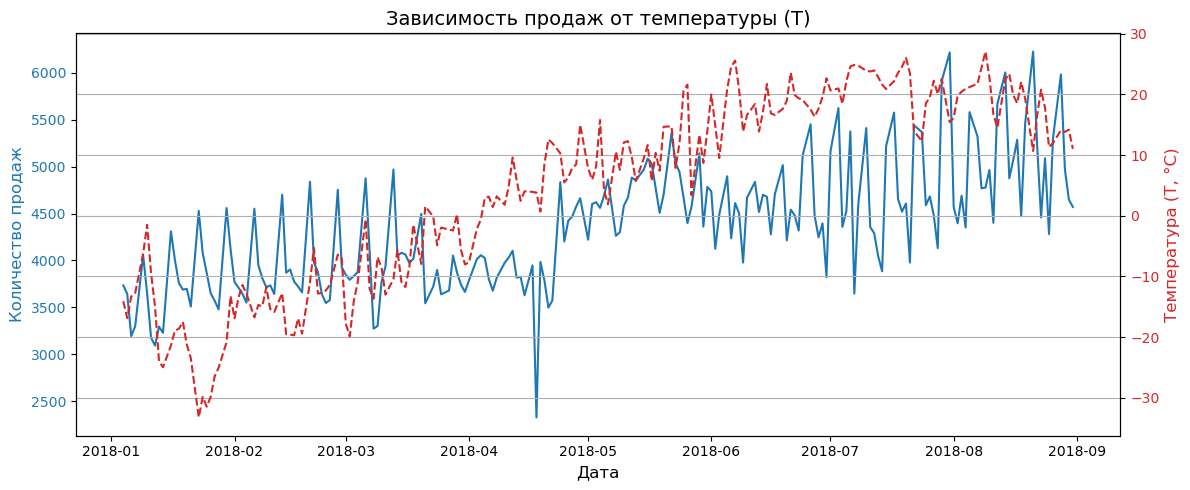

In [39]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Ось Y1 (левая) — Количество продаж
color = 'tab:blue'
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', color=color, fontsize=12)
ax1.plot(merged_df['Дата'], merged_df['Количество продаж'], color=color, label='Количество продаж')
ax1.tick_params(axis='y', labelcolor=color)

# Ось Y2 (правая) — Температура (T)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Температура (T, °C)', color=color, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color=color, linestyle='--', label='Температура (T)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Зависимость продаж от температуры (T)', fontsize=14)
plt.grid(True)
fig.tight_layout()
plt.show()

In [ ]:
# 2. Отдельный график температуры (T)

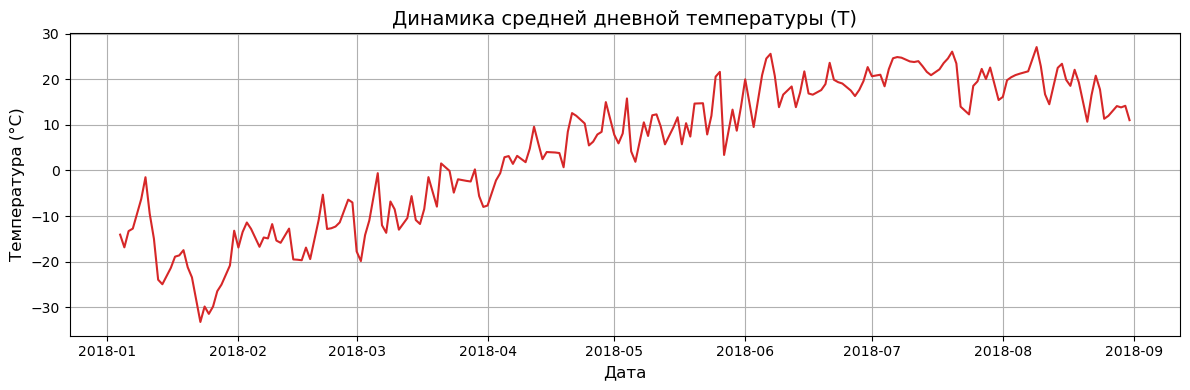

In [40]:
plt.figure(figsize=(12, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='tab:red', linewidth=1.5)

plt.title('Динамика средней дневной температуры (T)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Вывод: Между температурой и продажами наблюдается прямая корреляция — с повышением среднесуточной температуры количество продаж растёт.
# В холодный период (с января по апрель) объём продаж остаётся минимальным, а с мая начинается стабильный рост спроса.
# Максимум продаж приходится на летние месяцы — июль и август.
